# Skin Cancer Lesion Classification Using Deep Learning

## Models
1. EfficientNetB0
2. ResNet50

## Dataset
HAM10000

## Task
7-class skin lesion classification

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
import os
from google.colab import userdata

kaggle_token = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle API token loaded successfully!")

Kaggle API token loaded successfully!


In [3]:
!pip install -q kaggle

In [3]:
import os

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

print("Kaggle authentication configured!")

Kaggle authentication configured!


In [4]:
!kaggle datasets list -s HAM10000

ref                                                          title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                            Skin Cancer MNIST: HAM10000                       5582914511  2018-09-20 20:36:13.037000         285550       2402  0.7058824        
surajghuwalewala/ham1000-segmentation-and-classification     Skin cancer: HAM10000                             2781385274  2021-05-27 09:08:46.813000          21285        156  0.9411765        
tschandl/ham10000-lesion-segmentations                       HAM10000 Lesion Segmentations                       10766207  2020-07-02 21:20:22.710000           3685         36  0.875            
nightfury007/ham10000-isi

In [6]:
!mkdir -p /content/HAM10000

!kaggle datasets download \
    -d kmader/skin-cancer-mnist-ham10000 \
    -p /content/HAM10000 \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:46<00:00, 121MB/s]



In [7]:
import os

for root, dirs, files in os.walk("/content/HAM10000"):
    print(root, "->", len(files), "files")

/content/HAM10000 -> 5 files
/content/HAM10000/ham10000_images_part_1 -> 5000 files
/content/HAM10000/HAM10000_images_part_2 -> 5015 files
/content/HAM10000/HAM10000_images_part_1 -> 5000 files
/content/HAM10000/ham10000_images_part_2 -> 5015 files


In [8]:
import os

for file in os.listdir("/content/HAM10000"):
    print(file)

ham10000_images_part_1
HAM10000_images_part_2
hmnist_8_8_L.csv
HAM10000_metadata.csv
HAM10000_images_part_1
hmnist_28_28_L.csv
ham10000_images_part_2
hmnist_28_28_RGB.csv
hmnist_8_8_RGB.csv


In [9]:
metadata_path = "/content/HAM10000/HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First 5 rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [10]:
print("Number of classes:", df["dx"].nunique())

print("\nClasses:")
print(df["dx"].unique())

Number of classes: 7

Classes:
['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [11]:
class_counts = df["dx"].value_counts()

print(class_counts)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


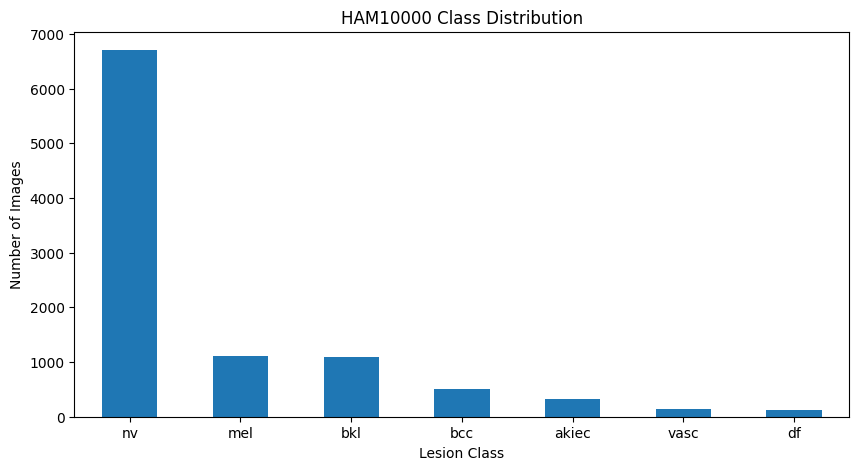

In [12]:
plt.figure(figsize=(10, 5))

class_counts.plot(kind="bar")

plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

In [13]:
print("Total images:", len(df))
print("Unique image IDs:", df["image_id"].nunique())
print("Unique lesion IDs:", df["lesion_id"].nunique())

print("\nImages per lesion:")
print(df["lesion_id"].value_counts().describe())

Total images: 10015
Unique image IDs: 10015
Unique lesion IDs: 7470

Images per lesion:
count    7470.000000
mean        1.340696
std         0.633970
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: count, dtype: float64


In [14]:
duplicate_lesions = df["lesion_id"].value_counts()

print("Lesions with more than one image:",
      (duplicate_lesions > 1).sum())

print("\nSome lesions with multiple images:")
print(duplicate_lesions[duplicate_lesions > 1].head(10))

Lesions with more than one image: 1956

Some lesions with multiple images:
lesion_id
HAM_0003789    6
HAM_0005263    6
HAM_0000835    6
HAM_0001863    6
HAM_0000893    5
HAM_0007427    5
HAM_0007343    5
HAM_0002364    5
HAM_0007367    5
HAM_0000889    4
Name: count, dtype: int64


In [15]:
lesion_class_check = df.groupby("lesion_id")["dx"].nunique()

print("Lesions with multiple diagnosis labels:",
      (lesion_class_check > 1).sum())

print("Maximum number of diagnosis labels for one lesion:",
      lesion_class_check.max())

Lesions with multiple diagnosis labels: 0
Maximum number of diagnosis labels for one lesion: 1


In [16]:
lesion_df = df[["lesion_id", "dx"]].drop_duplicates()

print("Unique lesions:", len(lesion_df))
print("\nLesion class distribution:")
print(lesion_df["dx"].value_counts())

Unique lesions: 7470

Lesion class distribution:
dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
train_lesions, temp_lesions = train_test_split(
    lesion_df,
    test_size=0.30,
    stratify=lesion_df["dx"],
    random_state=42
)

# Second split: divide the 30% into 15% validation and 15% test
val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.50,
    stratify=temp_lesions["dx"],
    random_state=42
)

print("Training lesions:", len(train_lesions))
print("Validation lesions:", len(val_lesions))
print("Test lesions:", len(test_lesions))

Training lesions: 5229
Validation lesions: 1120
Test lesions: 1121


In [18]:
train_df = df[df["lesion_id"].isin(train_lesions["lesion_id"])].copy()

val_df = df[df["lesion_id"].isin(val_lesions["lesion_id"])].copy()

test_df = df[df["lesion_id"].isin(test_lesions["lesion_id"])].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Training images: 7002
Validation images: 1532
Test images: 1481

Total: 10015


In [19]:
print("TRAINING")
print(train_df["dx"].value_counts())

print("\nVALIDATION")
print(val_df["dx"].value_counts())

print("\nTEST")
print(test_df["dx"].value_counts())

TRAINING
dx
nv       4679
mel       778
bkl       774
bcc       366
akiec     230
vasc       99
df         76
Name: count, dtype: int64

VALIDATION
dx
nv       1034
mel       170
bkl       157
bcc        77
akiec      51
vasc       24
df         19
Name: count, dtype: int64

TEST
dx
nv       992
bkl      168
mel      165
bcc       71
akiec     46
df        20
vasc      19
Name: count, dtype: int64


In [20]:
import glob
import os

image_files = glob.glob(
    "/content/HAM10000/**/*.jpg",
    recursive=True
)

print("Total JPG files found:", len(image_files))

# Remove duplicate file paths
image_files = list(set(image_files))

print("Unique JPG files found:", len(image_files))

Total JPG files found: 20030
Unique JPG files found: 20030


In [21]:
image_path_dict = {}

for path in image_files:
    image_id = os.path.splitext(os.path.basename(path))[0]
    image_path_dict[image_id] = path

print("Images mapped:", len(image_path_dict))

Images mapped: 10015


In [23]:
train_df["image_path"] = train_df["image_id"].map(image_path_dict)
val_df["image_path"] = val_df["image_id"].map(image_path_dict)
test_df["image_path"] = test_df["image_id"].map(image_path_dict)

In [24]:

print("Missing training paths:", train_df["image_path"].isna().sum())
print("Missing validation paths:", val_df["image_path"].isna().sum())
print("Missing test paths:", test_df["image_path"].isna().sum())

Missing training paths: 0
Missing validation paths: 0
Missing test paths: 0


Image path: /content/HAM10000/HAM10000_images_part_1/ISIC_0026769.jpg
Image size: (600, 450)
Image mode: RGB


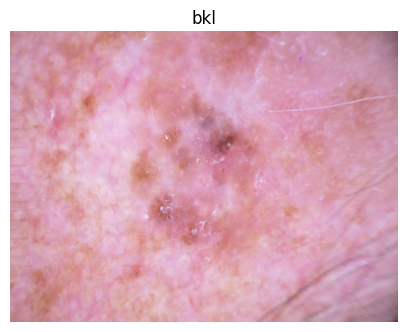

In [25]:
from PIL import Image

sample_path = train_df.iloc[0]["image_path"]

image = Image.open(sample_path)

print("Image path:", sample_path)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(train_df.iloc[0]["dx"])
plt.show()

In [26]:
label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6
}

class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

train_df["label"] = train_df["dx"].map(label_map)
val_df["label"] = val_df["dx"].map(label_map)
test_df["label"] = test_df["dx"].map(label_map)

print(train_df[["image_id", "dx", "label"]].head())

       image_id   dx  label
2  ISIC_0026769  bkl      2
3  ISIC_0025661  bkl      2
4  ISIC_0031633  bkl      2
5  ISIC_0027850  bkl      2
6  ISIC_0029176  bkl      2


In [27]:
print("Training labels:", sorted(train_df["label"].unique()))
print("Validation labels:", sorted(val_df["label"].unique()))
print("Test labels:", sorted(test_df["label"].unique()))

Training labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Validation labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Test labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [28]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 7

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: 224
Batch size: 32
Number of classes: 7


In [41]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    return image, label

In [42]:
def create_dataset(dataframe, shuffle=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [43]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

print("TensorFlow datasets created successfully!")

TensorFlow datasets created successfully!


In [44]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image pixel range:", images.numpy().min(), "to", images.numpy().max())
print("Labels:", labels.numpy()[:10])

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image pixel range: 0.0 to 255.0
Labels: [5 5 4 5 5 5 5 5 5 2]


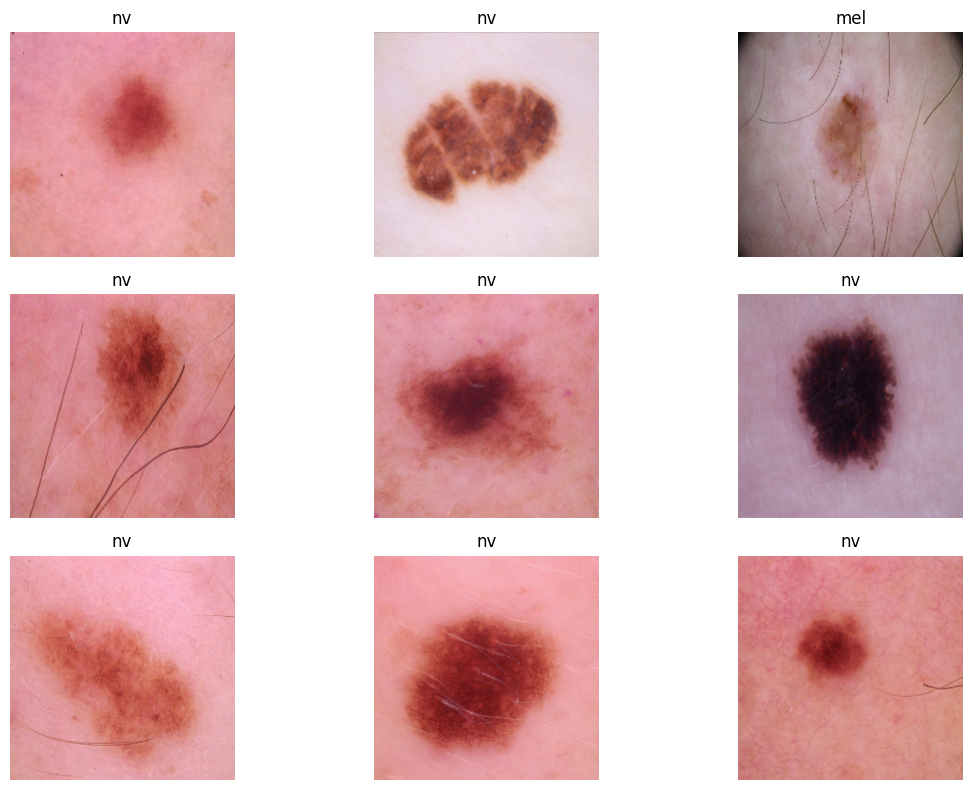

In [35]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array(sorted(train_df["label"].unique()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for label, weight in class_weight_dict.items():
    print(f"{label} ({class_names[label]}): {weight:.2f}")

Class weights:
0 (akiec): 4.35
1 (bcc): 2.73
2 (bkl): 1.29
3 (df): 13.16
4 (mel): 1.29
5 (nv): 0.21
6 (vasc): 10.10


In [37]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Load EfficientNetB0 without its original classification layer
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the pretrained layers for the first training phase
base_model.trainable = False

# Build classifier
model_efficientnet = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

print("EfficientNetB0 model created successfully!")

model_efficientnet.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [38]:
model_efficientnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 compiled successfully!")

EfficientNetB0 compiled successfully!


In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_efficientnetb0.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks created successfully!")

Callbacks created successfully!


In [40]:
history_efficientnet = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.1171 - loss: 1.9502
Epoch 1: val_loss improved from None to 1.84001, saving model to best_efficientnetb0.keras

Epoch 1: finished saving model to best_efficientnetb0.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 133s 460ms/step - accuracy: 0.1025 - loss: 1.9933 - val_accuracy: 0.6749 - val_loss: 1.8400 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.0931 - loss: 1.9595
Epoch 2: val_loss did not improve from 1.84001
219/219 ━━━━━━━━━━━━━━━━━━━━ 44s 201ms/step - accuracy: 0.0908 - loss: 1.9962 - val_accuracy: 0.1025 - val_loss: 1.9518 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.0833 - loss: 1.9895
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 3: val_loss did not improve from 1.84001
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 183ms/step - accuracy: 0.1010 - loss: 1.9933 - val_accuracy: 0.0124 - val_loss: 2.0357 - l

In [45]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)
test_ds = create_dataset(test_df, shuffle=False)

print("Datasets recreated with corrected preprocessing!")

Datasets recreated with corrected preprocessing!


In [46]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print(
    "Image pixel range:",
    images.numpy().min(),
    "to",
    images.numpy().max()
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image pixel range: 0.0 to 255.0


## EfficientNetB0 — Corrected Training

In [47]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained layers
base_model.trainable = False

model_efficientnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

print("EfficientNetB0 rebuilt successfully!")

EfficientNetB0 rebuilt successfully!


In [48]:
model_efficientnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 compiled successfully!")

EfficientNetB0 compiled successfully!


In [49]:
# Take one batch from the validation dataset
images, labels = next(iter(val_ds))

# Make predictions
predictions = model_efficientnet.predict(images, verbose=0)

print("Prediction shape:", predictions.shape)
print("First prediction:", predictions[0])
print("Sum of probabilities:", predictions[0].sum())
print("Predicted class:", np.argmax(predictions[0]))
print("Actual class:", labels[0].numpy())

Prediction shape: (32, 7)
First prediction: [0.14470959 0.15187313 0.18172061 0.10136604 0.13923103 0.15975447
 0.12134511]
Sum of probabilities: 0.99999994
Predicted class: 2
Actual class: 2


In [50]:
history_efficientnet = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.3890 - loss: 1.7684
Epoch 1: val_loss improved from 1.84001 to 1.16783, saving model to best_efficientnetb0.keras

Epoch 1: finished saving model to best_efficientnetb0.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 88s 293ms/step - accuracy: 0.4472 - loss: 1.6011 - val_accuracy: 0.6208 - val_loss: 1.1678 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.5534 - loss: 1.2106
Epoch 2: val_loss did not improve from 1.16783
219/219 ━━━━━━━━━━━━━━━━━━━━ 44s 202ms/step - accuracy: 0.5536 - loss: 1.2418 - val_accuracy: 0.5607 - val_loss: 1.2257 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5747 - loss: 1.1435
Epoch 3: val_loss improved from 1.16783 to 1.14195, saving model to best_efficientnetb0.keras

Epoch 3: finished saving model to best_efficientnetb0.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 41s 185ms/step - accuracy: 0.5770 - loss: 1.1231 - val_accurac

In [51]:
# Unfreeze the EfficientNetB0 base model
base_model.trainable = True

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 238
Trainable layers: 238


In [52]:
# Keep the early layers frozen
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep the last 30 layers trainable
for layer in base_model.layers[-30:]:
    layer.trainable = True

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))
print("Frozen layers:", sum(not layer.trainable for layer in base_model.layers))

Total layers: 238
Trainable layers: 30
Frozen layers: 208


In [53]:
model_efficientnet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 recompiled for fine-tuning!")

EfficientNetB0 recompiled for fine-tuning!


In [54]:
fine_tune_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_efficientnetb0_finetuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Fine-tuning callbacks created successfully!")

Fine-tuning callbacks created successfully!


In [55]:
history_finetune = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=fine_tune_callbacks
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.3370 - loss: 1.3325
Epoch 1: val_loss improved from None to 1.54481, saving model to best_efficientnetb0_finetuned.keras

Epoch 1: finished saving model to best_efficientnetb0_finetuned.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 102s 320ms/step - accuracy: 0.3430 - loss: 1.2816 - val_accuracy: 0.4621 - val_loss: 1.5448 - learning_rate: 1.0000e-05
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.4200 - loss: 1.1518
Epoch 2: val_loss improved from 1.54481 to 1.49492, saving model to best_efficientnetb0_finetuned.keras

Epoch 2: finished saving model to best_efficientnetb0_finetuned.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 99s 203ms/step - accuracy: 0.4233 - loss: 1.1430 - val_accuracy: 0.4641 - val_loss: 1.4949 - learning_rate: 1.0000e-05
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4642 - loss: 1.0048
Epoch 3: val_loss improved from 1.49492 to 1.39188, saving model to best_efficientnetb0_fine

In [56]:
model_efficientnet.load_weights("best_efficientnetb0.keras")

print("Best EfficientNetB0 weights loaded!")

Best EfficientNetB0 weights loaded!


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 62 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [57]:
test_loss, test_accuracy = model_efficientnet.evaluate(
    test_ds,
    verbose=1
)

print("\nEfficientNetB0 Test Results")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 424ms/step - accuracy: 0.6631 - loss: 0.9502

EfficientNetB0 Test Results
Test Loss: 0.9501520991325378
Test Accuracy: 0.663065493106842


In [58]:
# Generate predictions for the entire test set

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_efficientnet.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

True labels shape: (1481,)
Predicted labels shape: (1481,)


In [59]:
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

       akiec     0.3793    0.4783    0.4231        46
         bcc     0.3562    0.7324    0.4793        71
         bkl     0.4520    0.4762    0.4638       168
          df     0.1585    0.6500    0.2549        20
         mel     0.3594    0.4727    0.4084       165
          nv     0.9425    0.7268    0.8207       992
        vasc     0.4444    0.8421    0.5818        19

    accuracy                         0.6631      1481
   macro avg     0.4418    0.6255    0.4903      1481
weighted avg     0.7593    0.6631    0.6949      1481



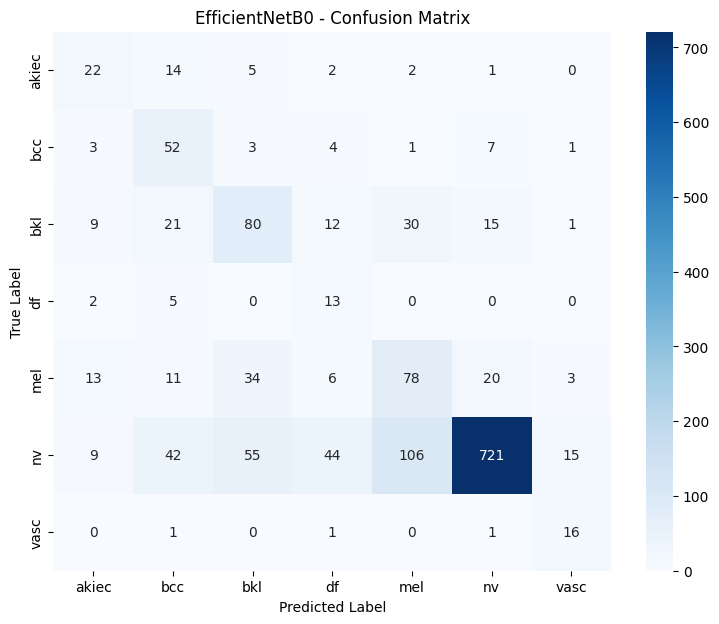

In [60]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 - Confusion Matrix")
plt.show()

In [61]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_resnet.trainable = False

model_resnet = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

print("ResNet50 model created successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 model created successfully!


In [62]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 compiled successfully!")

ResNet50 compiled successfully!


In [63]:
resnet_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_resnet50.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("ResNet50 callbacks created successfully!")

ResNet50 callbacks created successfully!


In [64]:
history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=resnet_callbacks
)


Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.3343 - loss: 2.0260
Epoch 1: val_loss improved from None to 1.17270, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 70s 251ms/step - accuracy: 0.4167 - loss: 1.6933 - val_accuracy: 0.5477 - val_loss: 1.1727 - learning_rate: 0.0010
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.5369 - loss: 1.1819
Epoch 2: val_loss did not improve from 1.17270
219/219 ━━━━━━━━━━━━━━━━━━━━ 42s 192ms/step - accuracy: 0.5383 - loss: 1.2203 - val_accuracy: 0.5313 - val_loss: 1.2378 - learning_rate: 0.0010
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5797 - loss: 1.0284
Epoch 3: val_loss improved from 1.17270 to 1.09439, saving model to best_resnet50.keras

Epoch 3: finished saving model to best_resnet50.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 43s 197ms/step - accuracy: 0.5880 - loss: 1.0318 - val_accuracy: 0.5842 - val_loss: 1.094

In [65]:
model_resnet.load_weights("best_resnet50.keras")

print("Best ResNet50 weights loaded!")

Best ResNet50 weights loaded!


In [66]:
test_loss_resnet, test_accuracy_resnet = model_resnet.evaluate(
    test_ds,
    verbose=1
)

print("\nResNet50 Test Results")
print("Test Loss:", test_loss_resnet)
print("Test Accuracy:", test_accuracy_resnet)

47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - accuracy: 0.6563 - loss: 0.9409

ResNet50 Test Results
Test Loss: 0.9409209489822388
Test Accuracy: 0.6563133001327515


In [67]:
y_true_resnet = []
y_pred_resnet = []

for images, labels in test_ds:
    predictions = model_resnet.predict(images, verbose=0)

    y_true_resnet.extend(labels.numpy())
    y_pred_resnet.extend(np.argmax(predictions, axis=1))

y_true_resnet = np.array(y_true_resnet)
y_pred_resnet = np.array(y_pred_resnet)

print("True labels shape:", y_true_resnet.shape)
print("Predicted labels shape:", y_pred_resnet.shape)

True labels shape: (1481,)
Predicted labels shape: (1481,)


In [68]:
print(classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

       akiec     0.2828    0.6087    0.3862        46
         bcc     0.3786    0.5493    0.4483        71
         bkl     0.4177    0.5893    0.4889       168
          df     0.1915    0.4500    0.2687        20
         mel     0.3800    0.4606    0.4164       165
          nv     0.9441    0.7157    0.8142       992
        vasc     0.2558    0.5789    0.3548        19

    accuracy                         0.6563      1481
   macro avg     0.4072    0.5647    0.4539      1481
weighted avg     0.7549    0.6563    0.6889      1481



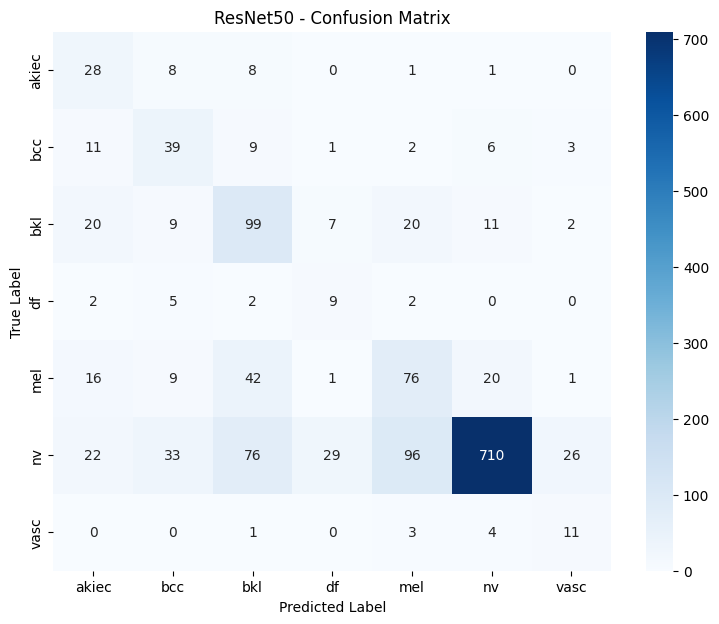

In [69]:
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 - Confusion Matrix")
plt.show()

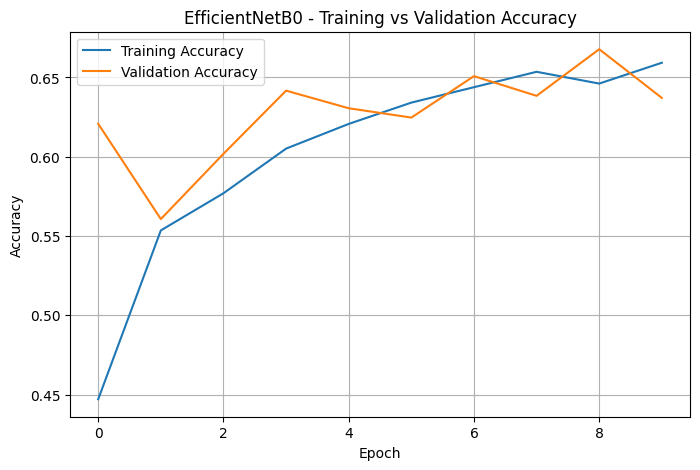

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_efficientnet.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_efficientnet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

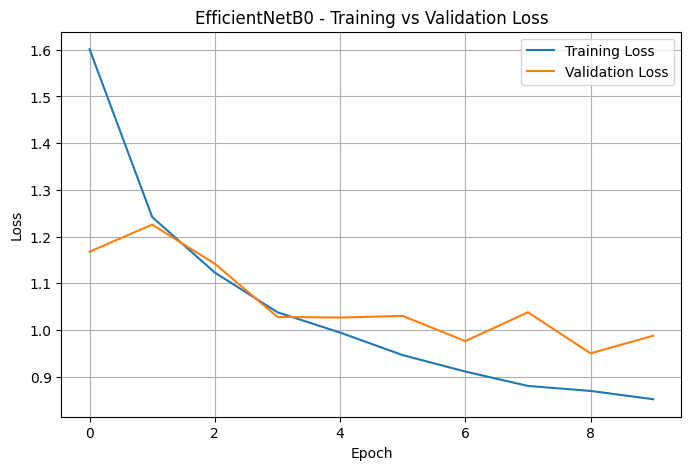

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_efficientnet.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_efficientnet.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 - Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

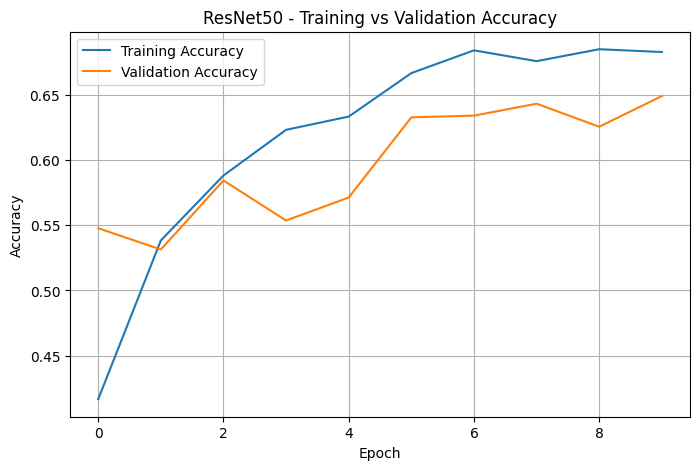

In [72]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_resnet.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_resnet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

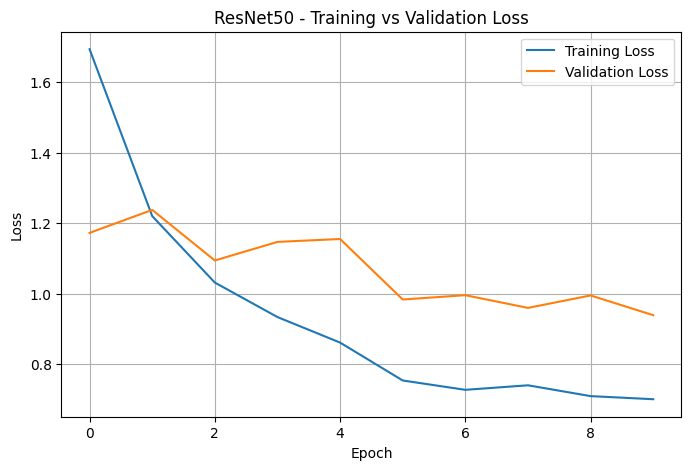

In [73]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_resnet.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_resnet.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 - Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [74]:
comparison = pd.DataFrame({
    "Metric": [
        "Best Validation Accuracy",
        "Best Validation Loss",
        "Test Accuracy",
        "Test Loss",
        "Macro F1-Score",
        "Weighted F1-Score"
    ],
    "EfficientNetB0": [
        66.78,
        0.9501,
        66.31,
        0.9502,
        49.03,
        69.49
    ],
    "ResNet50": [
        64.88,
        0.9393,
        65.63,
        0.9409,
        45.39,
        68.89
    ]
})

comparison

,Metric,EfficientNetB0,ResNet50
0,Best Validation Accuracy,66.7800,64.8800
1,Best Validation Loss,0.9501,0.9393
2,Test Accuracy,66.3100,65.6300
3,Test Loss,0.9502,0.9409
4,Macro F1-Score,49.0300,45.3900
5,Weighted F1-Score,69.4900,68.8900


In [75]:
comparison.style.format({
    "EfficientNetB0": "{:.2f}",
    "ResNet50": "{:.2f}"
}).hide(axis="index")

Metric,EfficientNetB0,ResNet50
Best Validation Accuracy,66.78,64.88
Best Validation Loss,0.95,0.94
Test Accuracy,66.31,65.63
Test Loss,0.95,0.94
Macro F1-Score,49.03,45.39
Weighted F1-Score,69.49,68.89


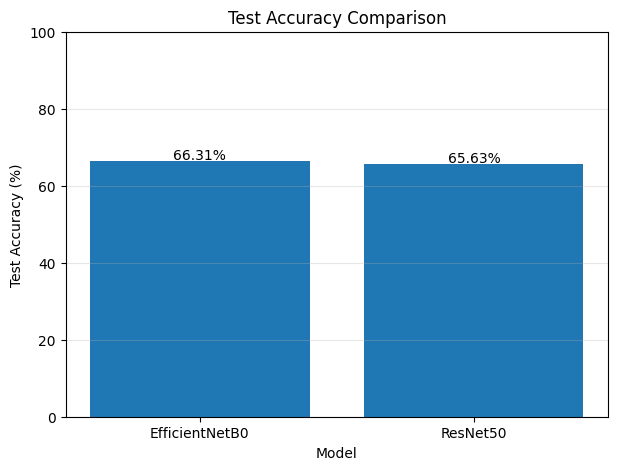

In [76]:
models_names = ["EfficientNetB0", "ResNet50"]
test_accuracies = [66.31, 65.63]

plt.figure(figsize=(7, 5))

plt.bar(models_names, test_accuracies)

plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison")

for i, value in enumerate(test_accuracies):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.show()

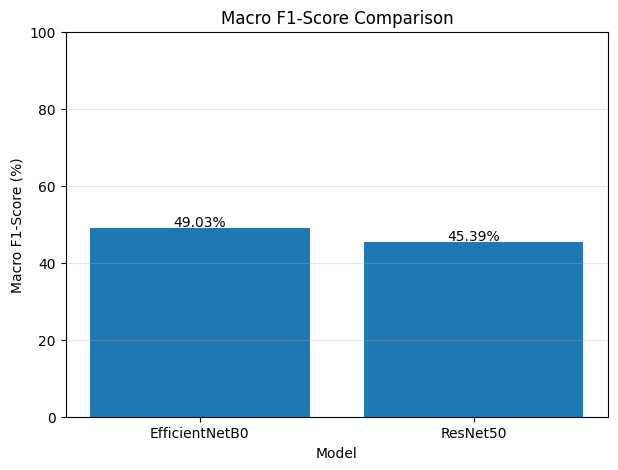

In [77]:
models_names = ["EfficientNetB0", "ResNet50"]
macro_f1_scores = [49.03, 45.39]

plt.figure(figsize=(7, 5))

plt.bar(models_names, macro_f1_scores)

plt.xlabel("Model")
plt.ylabel("Macro F1-Score (%)")
plt.title("Macro F1-Score Comparison")

for i, value in enumerate(macro_f1_scores):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [78]:
model_efficientnet.save("final_efficientnetb0.keras")

print("Final EfficientNetB0 model saved successfully!")

Final EfficientNetB0 model saved successfully!


In [79]:
import random

sample = test_df.sample(1, random_state=42).iloc[0]

image_path = sample["image_path"]
actual_label = sample["dx"]

print("Image path:", image_path)
print("Actual diagnosis:", actual_label)

Image path: /content/HAM10000/HAM10000_images_part_1/ISIC_0026263.jpg
Actual diagnosis: bkl


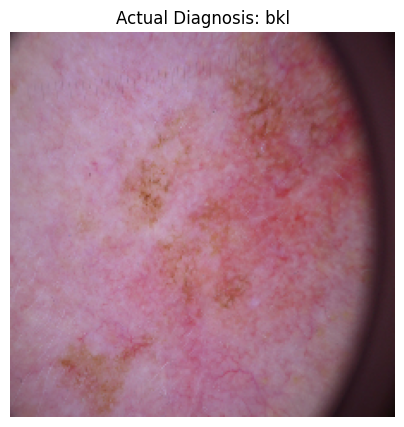

In [80]:
image = tf.io.read_file(image_path)
image = tf.image.decode_jpeg(image, channels=3)
image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

plt.figure(figsize=(5, 5))
plt.imshow(image.numpy().astype("uint8"))
plt.title(f"Actual Diagnosis: {actual_label}")
plt.axis("off")
plt.show()

In [81]:
# Prepare image for prediction
input_image = tf.expand_dims(image, axis=0)

# Make prediction
prediction = model_efficientnet.predict(input_image, verbose=0)

# Get predicted class
predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]

# Get confidence
confidence = prediction[0][predicted_index] * 100

print("Actual Diagnosis :", actual_label)
print("Predicted Diagnosis:", predicted_class)
print(f"Confidence        : {confidence:.2f}%")

Actual Diagnosis : bkl
Predicted Diagnosis: bkl
Confidence        : 31.39%


In [82]:
probabilities = prediction[0] * 100

for class_name, probability in zip(class_names, probabilities):
    print(f"{class_name:6s} : {probability:.2f}%")

akiec  : 23.94%
bcc    : 9.90%
bkl    : 31.39%
df     : 2.79%
mel    : 31.17%
nv     : 0.60%
vasc   : 0.21%


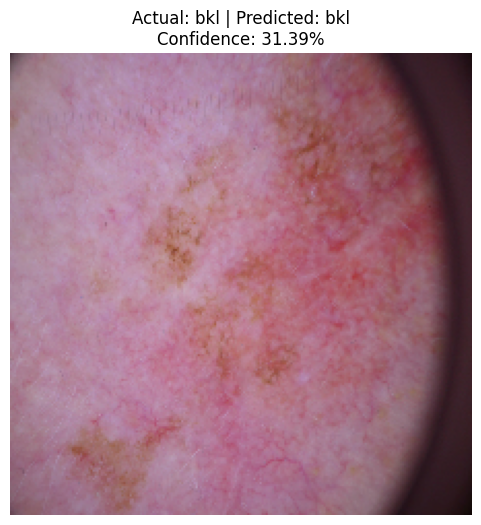

In [83]:
plt.figure(figsize=(6, 6))

plt.imshow(image.numpy().astype("uint8"))

plt.title(
    f"Actual: {actual_label} | "
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

In [84]:
# Select 5 test images
samples = test_df.sample(5, random_state=10)

for _, row in samples.iterrows():

    # Load image
    img = tf.io.read_file(row["image_path"])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    # Add batch dimension
    input_img = tf.expand_dims(img, axis=0)

    # Prediction
    pred = model_efficientnet.predict(input_img, verbose=0)

    predicted_index = np.argmax(pred[0])
    predicted_class = class_names[predicted_index]
    confidence = pred[0][predicted_index] * 100

    print("--------------------------------")
    print("Actual    :", row["dx"])
    print("Predicted :", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

--------------------------------
Actual    : nv
Predicted : mel
Confidence: 62.44%
--------------------------------
Actual    : bkl
Predicted : mel
Confidence: 49.70%
--------------------------------
Actual    : bkl
Predicted : bkl
Confidence: 83.40%
--------------------------------
Actual    : nv
Predicted : nv
Confidence: 96.07%
--------------------------------
Actual    : nv
Predicted : nv
Confidence: 88.10%


In [85]:
prediction_results = []

samples = test_df.sample(5, random_state=10)

for _, row in samples.iterrows():

    img = tf.io.read_file(row["image_path"])
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    input_img = tf.expand_dims(img, axis=0)

    pred = model_efficientnet.predict(input_img, verbose=0)

    predicted_index = np.argmax(pred[0])
    predicted_class = class_names[predicted_index]
    confidence = pred[0][predicted_index] * 100

    prediction_results.append({
        "Image ID": row["image_id"],
        "Actual": row["dx"],
        "Predicted": predicted_class,
        "Confidence (%)": confidence,
        "Correct": row["dx"] == predicted_class
    })

prediction_results_df = pd.DataFrame(prediction_results)

prediction_results_df

,Image ID,Actual,Predicted,Confidence (%),Correct
0,ISIC_0032428,nv,mel,62.441284,False
1,ISIC_0033130,bkl,mel,49.695076,False
2,ISIC_0033750,bkl,bkl,83.402290,True
3,ISIC_0032001,nv,nv,96.072693,True
4,ISIC_0030540,nv,nv,88.103981,True


In [86]:
sample_accuracy = prediction_results_df["Correct"].mean() * 100

print(f"Sample Prediction Accuracy: {sample_accuracy:.2f}%")

Sample Prediction Accuracy: 60.00%


In [87]:
final_accuracy = accuracy_score(y_true, y_pred)

final_precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

final_recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

final_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

final_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print("Final EfficientNetB0 Results")
print("----------------------------")
print(f"Accuracy       : {final_accuracy * 100:.2f}%")
print(f"Precision      : {final_precision * 100:.2f}%")
print(f"Recall         : {final_recall * 100:.2f}%")
print(f"Weighted F1    : {final_f1 * 100:.2f}%")
print(f"Macro F1       : {final_macro_f1 * 100:.2f}%")

Final EfficientNetB0 Results
----------------------------
Accuracy       : 66.31%
Precision      : 75.93%
Recall         : 66.31%
Weighted F1    : 69.49%
Macro F1       : 49.03%


In [88]:
final_results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score",
        "Macro F1-Score"
    ],
    "EfficientNetB0": [
        66.31,
        75.93,
        66.31,
        69.49,
        49.03
    ]
})

final_results.style.format({
    "EfficientNetB0": "{:.2f}%"
}).hide(axis="index")

Metric,EfficientNetB0
Test Accuracy,66.31%
Weighted Precision,75.93%
Weighted Recall,66.31%
Weighted F1-Score,69.49%
Macro F1-Score,49.03%


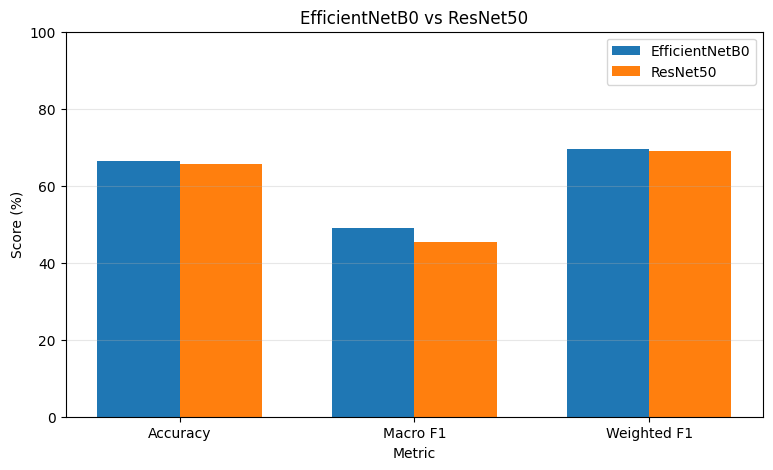

In [89]:
metrics = ["Accuracy", "Macro F1", "Weighted F1"]

efficientnet_scores = [66.31, 49.03, 69.49]
resnet_scores = [65.63, 45.39, 68.89]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    efficientnet_scores,
    width,
    label="EfficientNetB0"
)

plt.bar(
    x + width/2,
    resnet_scores,
    width,
    label="ResNet50"
)

plt.xlabel("Metric")
plt.ylabel("Score (%)")
plt.title("EfficientNetB0 vs ResNet50")

plt.xticks(x, metrics)
plt.ylim(0, 100)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

# Conclusion

This project developed a deep learning-based system for classifying skin lesions using the HAM10000 dataset. Two transfer learning architectures, EfficientNetB0 and ResNet50, were trained and evaluated for seven-class skin lesion classification.

EfficientNetB0 achieved a test accuracy of 66.31%, with a weighted precision of 75.93%, weighted F1-score of 69.49%, and macro F1-score of 49.03%. ResNet50 achieved a test accuracy of 65.63%.

Based on the overall test performance, EfficientNetB0 was selected as the final model.

The results demonstrate that transfer learning can be used to classify different types of skin lesions. However, the model still has difficulty distinguishing visually similar classes such as melanocytic nevi (nv), benign keratosis-like lesions (bkl), and melanoma (mel). Performance on minority classes such as dermatofibroma (df) is also limited.

Therefore, the developed system should be considered an academic/research prototype rather than a medical diagnostic tool.

## Limitations

- The HAM10000 dataset has significant class imbalance.
- Minority classes contain relatively few images.
- Several visually similar lesion classes are frequently confused.
- The overall macro F1-score is considerably lower than the weighted F1-score.
- The model has not been clinically validated.
- The system should not be used for medical diagnosis without appropriate clinical validation.

## Future Improvements

- Use stronger data augmentation techniques.
- Experiment with additional CNN architectures.
- Investigate focal loss or other methods for handling class imbalance.
- Perform more extensive hyperparameter tuning.
- Use a larger and more diverse dataset.
- Apply model explainability techniques such as Grad-CAM.
- Perform external/clinical validation before considering real-world use.

# Project Summary

## Project Title
**Skin Cancer Lesion Classification Using Deep Learning**

## Objective
To develop a deep learning-based image classification system capable of classifying skin lesions into seven different categories using the HAM10000 dataset.

## Dataset
**HAM10000 (Human Against Machine with 10000 training images)**

- Total images: 10,015
- Number of classes: 7
- Image size used for training: 224 × 224 pixels
- Dataset split:
  - Training: 7,002 images
  - Validation: 1,532 images
  - Testing: 1,481 images

## Classes

| Label | Diagnosis |
|---|---|
| akiec | Actinic keratoses / intraepithelial carcinoma |
| bcc | Basal cell carcinoma |
| bkl | Benign keratosis-like lesions |
| df | Dermatofibroma |
| mel | Melanoma |
| nv | Melanocytic nevi |
| vasc | Vascular lesions |

## Models Used

### EfficientNetB0
- Transfer learning with ImageNet pretrained weights
- Initial feature extractor frozen
- Classification head trained
- Fine-tuning was also investigated

### ResNet50
- Transfer learning with ImageNet pretrained weights
- Classification head trained
- Used as a comparison model

## Final Results

| Metric | EfficientNetB0 | ResNet50 |
|---|---:|---:|
| Test Accuracy | **66.31%** | 65.63% |
| Weighted Precision | **75.93%** | 75.49% |
| Weighted F1-Score | **69.49%** | 68.89% |
| Macro F1-Score | **49.03%** | 45.39% |

## Final Model

**EfficientNetB0** was selected as the final model because it achieved better overall test accuracy and macro/weighted F1-scores than ResNet50.

Final model file:

`final_efficientnetb0.keras`

## Key Findings

- EfficientNetB0 performed slightly better overall than ResNet50.
- The `nv` class achieved the strongest classification performance.
- Considerable confusion was observed between `nv`, `mel`, and `bkl`.
- Minority classes such as `df` remain challenging.
- Class imbalance significantly affects balanced performance metrics.
- The model demonstrates the potential of transfer learning for skin lesion classification but requires further improvement and validation.

## Final Outcome

The project successfully demonstrates an end-to-end deep learning workflow:

**Dataset → Data Analysis → Preprocessing → Lesion-level Splitting → Class Weighting → Transfer Learning → Model Training → Evaluation → Comparison → Prediction → Final Model**

The resulting EfficientNetB0 model provides a working academic prototype for seven-class skin lesion classification.

In [90]:
import os

model_path = "/content/final_efficientnetb0.keras"

if os.path.exists(model_path):
    file_size = os.path.getsize(model_path) / (1024 * 1024)

    print("Final model found successfully!")
    print(f"Model path: {model_path}")
    print(f"Model size: {file_size:.2f} MB")
else:
    print("Final model file not found.")

Final model found successfully!
Model path: /content/final_efficientnetb0.keras
Model size: 27.79 MB


In [91]:
from google.colab import files

files.download("/content/final_efficientnetb0.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>